In [ ]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, confusion_matrix


# Configurações visuais
CORES = {
    "azul": "#2563EB",
    "verde": "#16A34A",
    "laranja": "#EA580C",
    "vermelho": "#DC2626",
    "roxo": "#7C3AED",
    "cinza": "#6B7280",
}
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "DejaVu Sans",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    }
)

###  CARGA DOS DADOS
- Apenas um cabeçalho markdown para indicar o início do carregamento dos dados.

- Lê o arquivo CSV com os dados (`archive/abt_churn.csv`), já convertendo a coluna `dtRef` para datetime.
- Define variáveis:
  - `TARGET`: variável alvo (“flagChurn” – indica se o cliente saiu/ficou)
  - `ID_COLS`: colunas de identificação que não serão usadas como preditoras
  - `FEATURES`: todas as colunas exceto ids e target (estas que compõem o conjunto de preditoras)
- Imprime:
  - Total de registros (linhas do dataset, ou seja, clientes/mês)
  - Quantidade de features (variáveis utilizadas como preditoras)
  - Quantidade de safras (meses distintos representados nos dados)
  - Proporção de “churners” (clientes que saíram) – importante para saber se o alvo é balanceado ou desbalanceado

In [ ]:
df = pd.read_csv("archive/abt_churn.csv", parse_dates=["dtRef"])

TARGET = "flagChurn"
ID_COLS = ["dtRef", "idUsuario"]
FEATURES = [c for c in df.columns if c not in ID_COLS + [TARGET]]


print(f"  Registros  : {df.shape[0]:,}")
print(f"  Features   : {len(FEATURES)}")
print(f"  Safras     : {df['dtRef'].nunique()} meses")
print(f"  Target (1) : {df[TARGET].mean():.1%}")


  Registros  : 5,496
  Features   : 40
  Safras     : 14 meses
  Target (1) : 47.1%


###  S — SAMPLE (Amostragem)

Passos:
- Define a última “safra” (mês mais recente) dos dados.
- Separa o dataframe em dois:
  - `df_oot`: safra mais recente (para simular previsão futura – OOT = Out Of Time)
  - `df_model`: todas as outras safras (para modelagem e validação “dentro do tempo”)
- Separa X (features), y (alvo) para os dados de modelagem.  
- Divide os dados de modelagem em treino e teste (80%/20%), de maneira estratificada (mantém proporção de churn nas duas amostras).
- Prepara objetos X/y também para a safra “OOT”.
- Imprime estatísticas das amostras:  
  - quantidade de registros por grupo
  - proporção do churn (alvo) em cada amostra – fundamental para checar se a separação ficou balanceada e realista.

In [ ]:
ultima_safra = df["dtRef"].max()
df_oot = df[df["dtRef"] == ultima_safra].copy()
df_model = df[df["dtRef"] < ultima_safra].copy()

X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_oot = df_oot[FEATURES]
y_oot = df_oot[TARGET]

print(
    f"  Safra OOT      : {ultima_safra.strftime('%Y-%m')}  → {len(df_oot):,} registros"
)
print(f"  Base modelagem : {len(df_model):,} registros")
print(f"  Treino         : {len(X_train):,}  | Churn = {y_train.mean():.1%}")
print(f"  Teste          : {len(X_test):,}   | Churn = {y_test.mean():.1%}")
print(f"  OOT            : {len(X_oot):,}    | Churn = {y_oot.mean():.1%}")

  Safra OOT      : 2025-04  → 303 registros
  Base modelagem : 5,193 registros
  Treino         : 4,154  | Churn = 46.9%
  Teste          : 1,039   | Churn = 46.9%
  OOT            : 303    | Churn = 50.5%


###  E — EXPLORE (Exploração) — somente na base de Treino

#### 1. Qualidade dos dados

Passos:
- Cria um dataframe de exploração, unindo X_train com y_train (para análises exploratórias).
- Conta quantas colunas apresentam “missing values” (valores ausentes).
- Imprime o total de colunas com missings.  
**Por quê?** Variáveis com valores faltantes podem precisar de tratamento (imputação) depois.

In [ ]:
df_treino_exp = X_train.copy()
df_treino_exp["target"] = y_train.values

missings = df_treino_exp.isnull().sum()
print(f"  Missings encontrados : {(missings > 0).sum()} colunas")

  Missings encontrados : 0 colunas


#### 2. Análise Bivariada

Passos:
- Calcula médias das features separadas por target (churn x não-churn).
- Mede para cada variável a diferença absoluta entre as médias desses dois grupos.
- Ordena do maior para o menor e mostra as 10 variáveis com maior diferença.
**Por quê?**  
Bons “separadores” no início provavelmente têm boas chances de serem importantes para o modelo final.


In [ ]:
biv = df_treino_exp.groupby("target")[FEATURES].mean()
diff = (biv.loc[1] - biv.loc[0]).abs().sort_values(ascending=False)
top10_biv = diff.head(10).index.tolist()
print(f"\n  Top 10 features por diferença de média (Churn vs Não-Churn):")
for f in top10_biv:
    print(f"    {f:<35} | μ_churn={biv.loc[1,f]:>10.2f}  μ_não={biv.loc[0,f]:>10.2f}")


  Top 10 features por diferença de média (Churn vs Não-Churn):
    qtdePontosPos                       | μ_churn=    648.48  μ_não=   3073.56
    qtdePontosNeg                       | μ_churn=   -209.17  μ_não=  -1621.83
    saldoPontos                         | μ_churn=    439.32  μ_não=   1451.73
    qtdePontosPosD28                    | μ_churn=    114.49  μ_não=    617.36
    qtdePontosPosD14                    | μ_churn=     38.11  μ_não=    316.51
    qtdePontosNegD28                    | μ_churn=    -21.77  μ_não=   -300.07
    qtdeTransacoes                      | μ_churn=     50.05  μ_não=    326.91
    qtdeChatMessage                     | μ_churn=     40.68  μ_não=    288.23
    saldoPontosD28                      | μ_churn=     92.72  μ_não=    317.29
    saldoPontosD14                      | μ_churn=     31.10  μ_não=    179.61


#### 3. Feature Importance Inicial (Decision Tree)

Passos:
- Treina um DecisionTreeClassifier raso (max_depth=5) para não sofrer overfitting.
- Mostra as importâncias das features segundo a árvore treinada.
- Lista as 10 variáveis com maior importância.
**Por quê?**  
É uma “prévia” de quais variáveis o modelo mais simples conseguiria usar para distinguir os grupos.

In [ ]:
dt_exp = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_exp.fit(X_train, y_train)
fi = pd.Series(dt_exp.feature_importances_, index=FEATURES).sort_values(ascending=False)
top10_fi = fi.head(10)
print(f"\n  Top 10 features por importância (Decision Tree):")
for f, v in top10_fi.items():
    print(f"    {f:<35} : {v:.4f}")


  Top 10 features por importância (Decision Tree):
    qtdeDiasD14                         : 0.6206
    propAvgQtdeDias                     : 0.1198
    qtdeDiasUltimaTransacao             : 0.0565
    qtdeTransacoesD7                    : 0.0420
    qtdePontosPosD7                     : 0.0355
    qtdeDiasD28                         : 0.0352
    qtdeTransacoesD28                   : 0.0191
    propAvgQtdePontosPos                : 0.0174
    propAvgMediaTransacoesDias          : 0.0148
    saldoPontosD14                      : 0.0070


###  M — MODIFY (Modificação)

-  Todas as features são numéricas — Pipeline com Imputer + Scaler

Passos:
- Cria um pipeline de pré-processamento só para as features (todas numéricas).
- O pipeline faz:
  1. Imputação de valores faltantes com mediana (`SimpleImputer(strategy="median")`)
  2. Padronização das features (`StandardScaler`).  
- Usa `ColumnTransformer` para aplicar o pipeline só nas features especificadas.
- Imprime quantas features entram no pipeline.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            FEATURES,
        )
    ],
    remainder="drop",
)

print(f"  Features no pipeline: {len(FEATURES)}")

  Features no pipeline: 40


####  M — MODEL (Modelagem)

Passos:
- Cria um Pipeline que une o pré-processamento e um RandomForestClassifier.
- Define um dicionário de parâmetros possíveis para o Random Forest (“grid” de busca).
- Usa RandomizedSearchCV para buscar as melhores combinações com validação cruzada (cross-validation, cv=5).
- Treina a busca de hiperparâmetro só no treino (X_train, y_train).
- Ao final, imprime o melhor valor de AUC médio e os melhores parâmetros encontrados.  
**Por quê?** Ganho de robustez (cross-validation), modelo mais ajustado para esse problema e sem “vazar” informações das amostras de teste/OOT.

In [ ]:
pipeline_completo = Pipeline(
    [("prep", preprocessor), ("rf", RandomForestClassifier(random_state=42, n_jobs=1))]
)

param_dist = {
    "rf__n_estimators": [100, 200, 300],
    "rf__max_depth": [5, 10, 15, None],
    "rf__min_samples_leaf": [5, 10, 20],
    "rf__max_features": ["sqrt", "log2"],
}

search = RandomizedSearchCV(
    pipeline_completo,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=1,
    verbose=0,
)

search.fit(X_train, y_train)

best_params = search.best_params_
best_cv_auc = search.best_score_
print(f"  Melhor AUC (CV treino) : {best_cv_auc:.4f}")
print(f"  Melhores parâmetros:")
for k, v in best_params.items():
    print(f"    {k}: {v}")

  Melhor AUC (CV treino) : 0.8168
  Melhores parâmetros:
    rf__n_estimators: 300
    rf__min_samples_leaf: 20
    rf__max_features: sqrt
    rf__max_depth: None


####  A — ASSESS (Avaliação)

Passos:
- Salva o melhor pipeline ajustado como “melhor_modelo”.
- Usa `.predict_proba()` para pegar as probabilidades de churn no treino, teste e OOT.
- Calcula as métricas principais:
  - ROC-AUC (capacidade do modelo em separar classes, quanto mais próximo de 1, melhor)
  - Acurácia (proporção de acertos)
- Imprime as métricas por amostra (treino, teste, OOT).
- Calcula o “gap de overfitting” (diferença de AUC entre treino e teste); se for pequeno, não há overfitting.  
- Cria uma tabela de lift/gains: simula dividir a base de teste em “decis” (10%, 20%, etc.) e verifica, para cada segmento, quantos churners o modelo captura.  
- O “lift” diz quantas vezes mais churners podem ser encontrados se focar em quem teve maior predição de churn (priorização/actionability).

In [ ]:
melhor_modelo = search.best_estimator_

# Probabilidades
y_prob_train = melhor_modelo.predict_proba(X_train)[:, 1]
y_prob_test = melhor_modelo.predict_proba(X_test)[:, 1]
y_prob_oot = melhor_modelo.predict_proba(X_oot)[:, 1]

# Métricas
auc_train = roc_auc_score(y_train, y_prob_train)
auc_test = roc_auc_score(y_test, y_prob_test)
auc_oot = roc_auc_score(y_oot, y_prob_oot)

acc_train = accuracy_score(y_train, melhor_modelo.predict(X_train))
acc_test = accuracy_score(y_test, melhor_modelo.predict(X_test))
acc_oot = accuracy_score(y_oot, melhor_modelo.predict(X_oot))

print(f"\n  {'Base':<12} | {'ROC AUC':>10} | {'Acurácia':>10}")
print(f"  {'-'*40}")
print(f"  {'Treino':<12} | {auc_train:>10.4f} | {acc_train:>10.1%}")
print(f"  {'Teste':<12} | {auc_test:>10.4f} | {acc_test:>10.1%}")
print(f"  {'OOT':<12} | {auc_oot:>10.4f} | {acc_oot:>10.1%}")

overfitting_gap = auc_train - auc_test
print(f"\n  Gap Overfitting (Treino-Teste): {overfitting_gap:.4f}", end="")
print("  ✓ OK" if overfitting_gap < 0.05 else "   Atenção: possível overfitting")

# ── Lift / Gains Table
df_lift = pd.DataFrame({"prob": y_prob_test, "alvo": y_test.values})
df_lift = df_lift.sort_values("prob", ascending=False).reset_index(drop=True)
total_churners = df_lift["alvo"].sum()

decis = [10, 20, 30, 40, 50]
print(f"\n  {'Decil':>6} | {'% Pop':>6} | {'Churners Capturados':>22} | {'Lift':>6}")
print(f"  {'-'*55}")
for d in decis:
    n = int(len(df_lift) * d / 100)
    cap = df_lift.iloc[:n]["alvo"].sum()
    pct_cap = cap / total_churners
    lift = pct_cap / (d / 100)
    print(
        f"  {d:>6}% | top {d}% | {cap:>5} de {total_churners:>5} ({pct_cap:>6.1%}) | {lift:>6.2f}x"
    )


[A] ASSESS ─────────────────────────────────────────

  Base         |    ROC AUC |   Acurácia
  ----------------------------------------
  Treino       |     0.8750 |      78.5%
  Teste        |     0.8255 |      75.5%
  OOT          |     0.8424 |      78.2%

  Gap Overfitting (Treino-Teste): 0.0495  ✓ OK

   Decil |  % Pop |    Churners Capturados |   Lift
  -------------------------------------------------------
      10% | top 10% |    83 de   487 ( 17.0%) |   1.70x
      20% | top 20% |   157 de   487 ( 32.2%) |   1.61x
      30% | top 30% |   236 de   487 ( 48.5%) |   1.62x
      40% | top 40% |   315 de   487 ( 64.7%) |   1.62x
      50% | top 50% |   375 de   487 ( 77.0%) |   1.54x


###  SERIALIZAÇÃO

- Usa `pickle` para salvar o pipeline ajustado em um arquivo (“models/modelo_churn_v1.pkl”).
- Isso permite usar o modelo treinado posteriormente para previsões em produção, sem refazer todo treino.


In [ ]:
with open("models/modelo_churn_v1.pkl", "wb") as f:
    pickle.dump(melhor_modelo, f)


  Modelo serializado → modelo_churn_v1.pkl


###  GRÁFICO 1 - Distribuição das Safras

Passos:
- Cria gráfico de barras mostrando, para cada safra (mês), a quantidade de clientes classificados como churn e não-churn.
- Mostra os números sobre cada barra – facilita enxergar sazonalidades e distribuição do target ao longo do tempo.


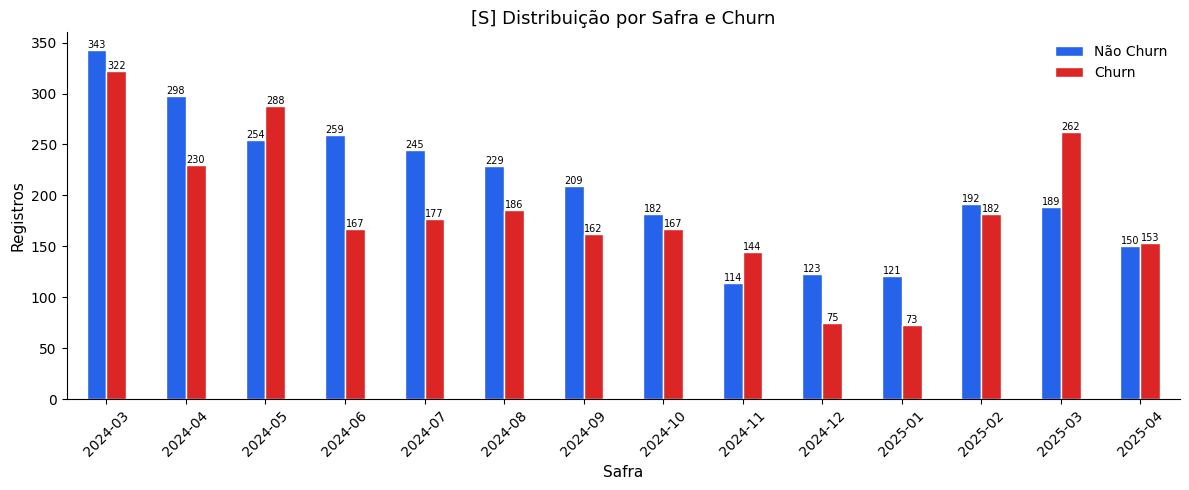

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
safras = df.groupby(["dtRef", TARGET]).size().unstack(fill_value=0)
safras.index = safras.index.strftime("%Y-%m")
safras.plot(
    kind="bar",
    ax=ax,
    color=[CORES["azul"], CORES["vermelho"]],
    edgecolor="white",
)
ax.set_title("[S] Distribuição por Safra e Churn")
ax.set_xlabel("Safra")
ax.set_ylabel("Registros")
ax.legend(["Não Churn", "Churn"], frameon=False)
ax.tick_params(axis="x", rotation=45)
for patch in ax.patches:
    h = patch.get_height()
    if h > 0:
        ax.annotate(
            f"{int(h)}",
            (patch.get_x() + patch.get_width() / 2, h),
            ha="center",
            va="bottom",
            fontsize=7,
        )
plt.tight_layout()
plt.show()

####  GRÁFICO 2 - Feature Importance do Random Forest Final

Passos:
- Extrai do pipeline ajustado o Random Forest treinado, e pega as importâncias das features.
- Exibe as 15 variáveis mais importantes na classificação final.
- Esse gráfico ajuda na interpretação do modelo (“explicabilidade”).

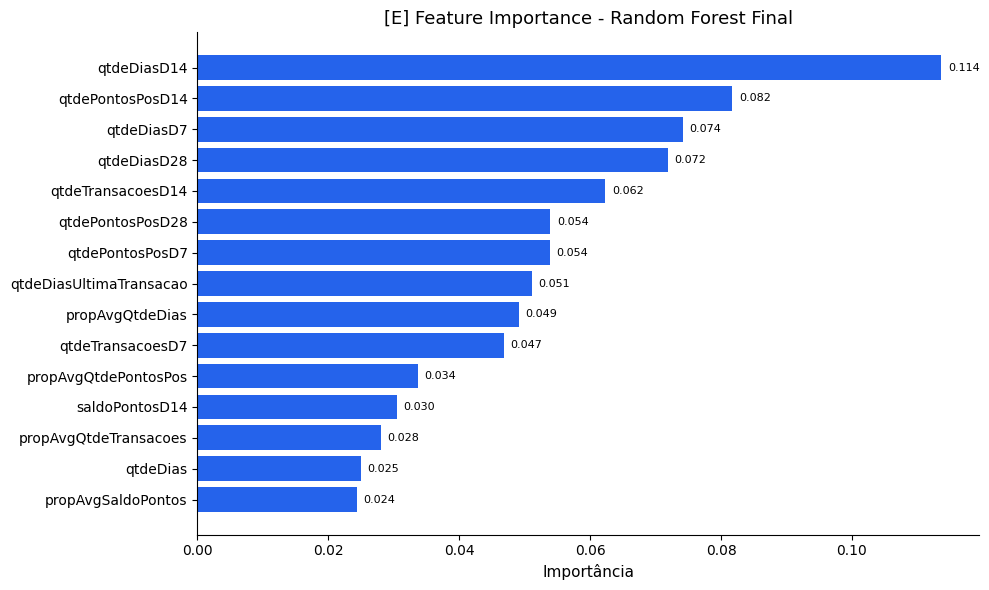

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
rf_final = melhor_modelo.named_steps["rf"]
fi_rf = (
    pd.Series(rf_final.feature_importances_, index=FEATURES)
    .sort_values(ascending=False)
    .head(15)
)
bars = ax.barh(fi_rf.index[::-1], fi_rf.values[::-1], color=CORES["azul"])
ax.set_title("[E] Feature Importance - Random Forest Final")
ax.set_xlabel("Importância")
for bar, val in zip(bars, fi_rf.values[::-1]):
    ax.text(
        val + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        fontsize=8,
    )
plt.tight_layout()
plt.show()

In [ ]:
'''
Preparação dos dados para os gráficos bivariados
Cada variável do top 8 será exibida em uma célula separada.
'''

top8 = fi.head(8).index.tolist()
df_biv_plot = df_treino_exp[top8 + ["target"]].copy()
print("Variáveis usadas na análise bivariada:")
display(pd.DataFrame({"variavel": top8}))

Variáveis usadas na análise bivariada:


,variavel
0,qtdeDiasD14
1,propAvgQtdeDias
2,qtdeDiasUltimaTransacao
3,qtdeTransacoesD7
4,qtdePontosPosD7
5,qtdeDiasD28
6,qtdeTransacoesD28
7,propAvgQtdePontosPos


####  GRÁFICO BIVARIADO 1 - Top 1 variável

- Mostra as 8 variáveis mais importantes (segundo a árvore), para depois serem usadas em gráficos detalhados de distribuição (one by one).
- Usa `display` para mostrar essas variáveis de modo tabulado (útil para facilitar a identificação visual para os gráficos seguintes).

Para cada uma das 8 principais variáveis:
- Cria um histograma da distribuição dessa variável, separando os grupos “churn” e “não churn” por cor.
- Ensaia interpretações visuais: variáveis que têm distribuições bem diferentes entre os grupos são candidatas a bons “separadores”.
- Isso complementa a análise quantitativa anterior, trazendo intuição visual.

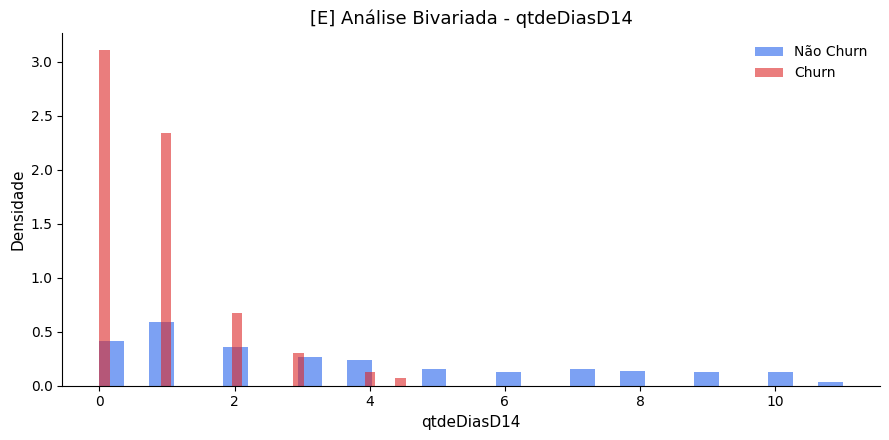

In [ ]:
feat = top8[0]
fig, ax = plt.subplots(figsize=(9, 4.5))
for cls, cor, lbl in [
    (0, CORES["azul"], "Não Churn"),
    (1, CORES["vermelho"], "Churn"),
]:
    vals = df_biv_plot[df_biv_plot["target"] == cls][feat]
    q1, q99 = vals.quantile(0.01), vals.quantile(0.99)
    vals_clip = vals.clip(q1, q99)
    ax.hist(vals_clip, bins=30, alpha=0.6, color=cor, label=lbl, density=True)
ax.set_title(f"[E] Análise Bivariada - {feat}")
ax.set_xlabel(feat)
ax.set_ylabel("Densidade")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

####  GRÁFICO BIVARIADO 2 - Top 2 variável

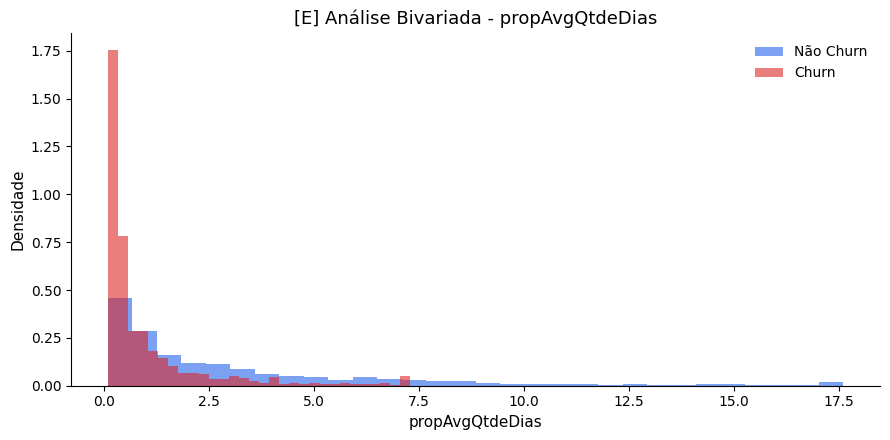

In [ ]:
feat = top8[1]
fig, ax = plt.subplots(figsize=(9, 4.5))
for cls, cor, lbl in [
    (0, CORES["azul"], "Não Churn"),
    (1, CORES["vermelho"], "Churn"),
]:
    vals = df_biv_plot[df_biv_plot["target"] == cls][feat]
    q1, q99 = vals.quantile(0.01), vals.quantile(0.99)
    vals_clip = vals.clip(q1, q99)
    ax.hist(vals_clip, bins=30, alpha=0.6, color=cor, label=lbl, density=True)
ax.set_title(f"[E] Análise Bivariada - {feat}")
ax.set_xlabel(feat)
ax.set_ylabel("Densidade")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

####  GRÁFICO BIVARIADO 3 - Top 3 variável

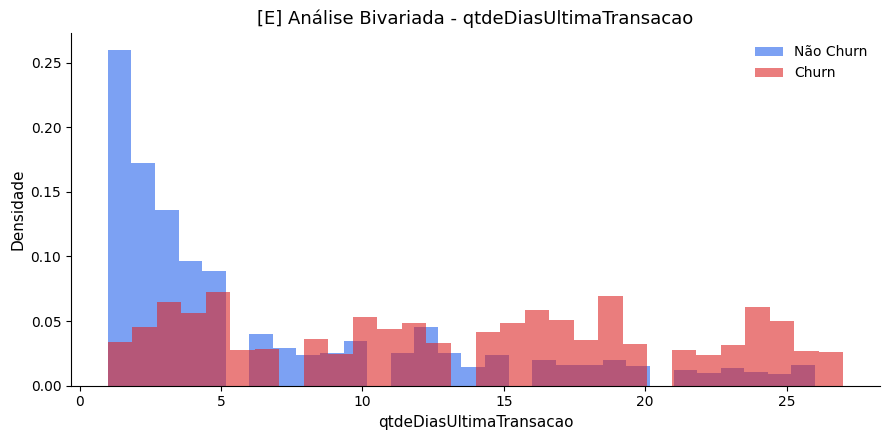

In [ ]:
feat = top8[2]
fig, ax = plt.subplots(figsize=(9, 4.5))
for cls, cor, lbl in [
    (0, CORES["azul"], "Não Churn"),
    (1, CORES["vermelho"], "Churn"),
]:
    vals = df_biv_plot[df_biv_plot["target"] == cls][feat]
    q1, q99 = vals.quantile(0.01), vals.quantile(0.99)
    vals_clip = vals.clip(q1, q99)
    ax.hist(vals_clip, bins=30, alpha=0.6, color=cor, label=lbl, density=True)
ax.set_title(f"[E] Análise Bivariada - {feat}")
ax.set_xlabel(feat)
ax.set_ylabel("Densidade")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

####  GRÁFICO BIVARIADO 4 - Top 4 variável

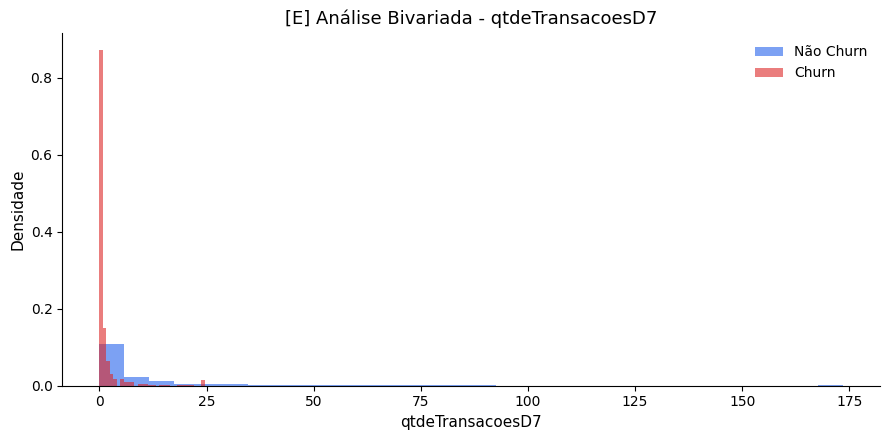

In [ ]:
feat = top8[3]
fig, ax = plt.subplots(figsize=(9, 4.5))
for cls, cor, lbl in [
    (0, CORES["azul"], "Não Churn"),
    (1, CORES["vermelho"], "Churn"),
]:
    vals = df_biv_plot[df_biv_plot["target"] == cls][feat]
    q1, q99 = vals.quantile(0.01), vals.quantile(0.99)
    vals_clip = vals.clip(q1, q99)
    ax.hist(vals_clip, bins=30, alpha=0.6, color=cor, label=lbl, density=True)
ax.set_title(f"[E] Análise Bivariada - {feat}")
ax.set_xlabel(feat)
ax.set_ylabel("Densidade")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

####  GRÁFICO BIVARIADO 5 - Top 5 variável

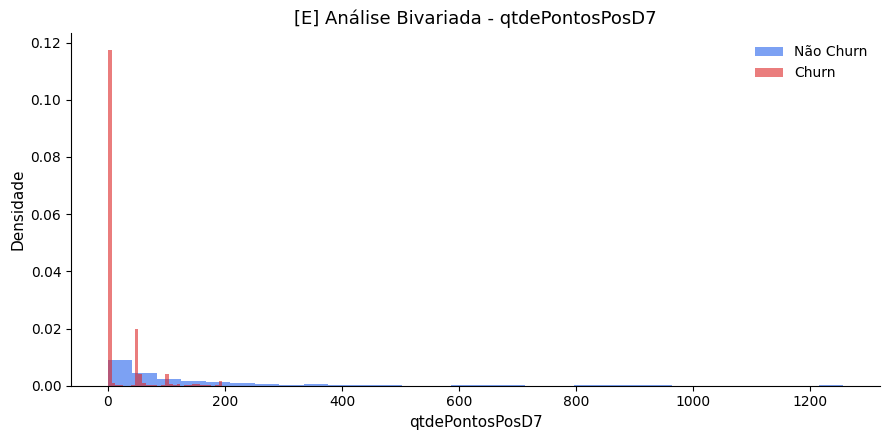

In [ ]:
feat = top8[4]
fig, ax = plt.subplots(figsize=(9, 4.5))
for cls, cor, lbl in [
    (0, CORES["azul"], "Não Churn"),
    (1, CORES["vermelho"], "Churn"),
]:
    vals = df_biv_plot[df_biv_plot["target"] == cls][feat]
    q1, q99 = vals.quantile(0.01), vals.quantile(0.99)
    vals_clip = vals.clip(q1, q99)
    ax.hist(vals_clip, bins=30, alpha=0.6, color=cor, label=lbl, density=True)
ax.set_title(f"[E] Análise Bivariada - {feat}")
ax.set_xlabel(feat)
ax.set_ylabel("Densidade")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

####  GRÁFICO BIVARIADO 6 - Top 6 variável

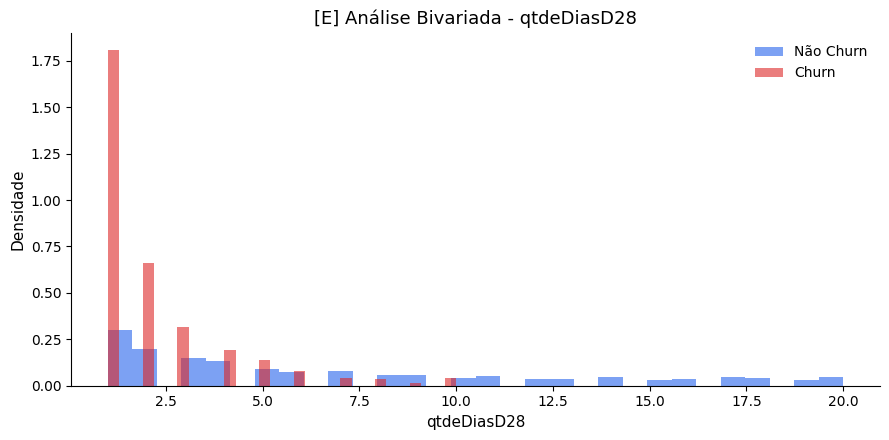

In [ ]:
feat = top8[5]
fig, ax = plt.subplots(figsize=(9, 4.5))
for cls, cor, lbl in [
    (0, CORES["azul"], "Não Churn"),
    (1, CORES["vermelho"], "Churn"),
]:
    vals = df_biv_plot[df_biv_plot["target"] == cls][feat]
    q1, q99 = vals.quantile(0.01), vals.quantile(0.99)
    vals_clip = vals.clip(q1, q99)
    ax.hist(vals_clip, bins=30, alpha=0.6, color=cor, label=lbl, density=True)
ax.set_title(f"[E] Análise Bivariada - {feat}")
ax.set_xlabel(feat)
ax.set_ylabel("Densidade")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

####  GRÁFICO BIVARIADO 7 - Top 7 variável

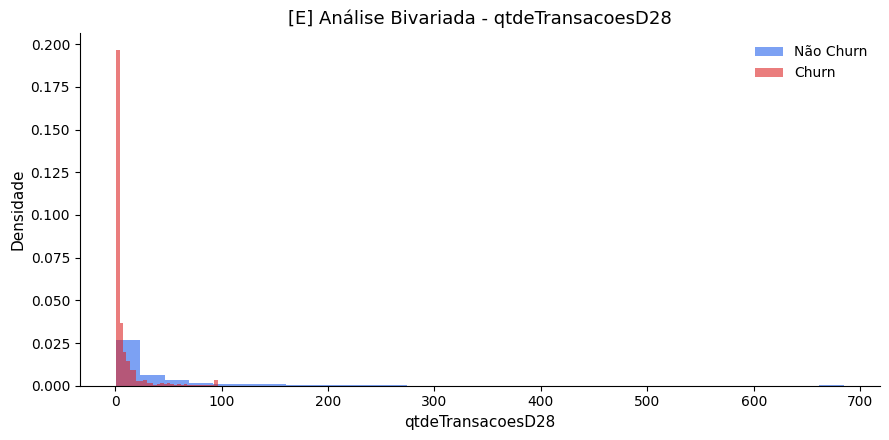

In [ ]:
feat = top8[6]
fig, ax = plt.subplots(figsize=(9, 4.5))
for cls, cor, lbl in [
    (0, CORES["azul"], "Não Churn"),
    (1, CORES["vermelho"], "Churn"),
]:
    vals = df_biv_plot[df_biv_plot["target"] == cls][feat]
    q1, q99 = vals.quantile(0.01), vals.quantile(0.99)
    vals_clip = vals.clip(q1, q99)
    ax.hist(vals_clip, bins=30, alpha=0.6, color=cor, label=lbl, density=True)
ax.set_title(f"[E] Análise Bivariada - {feat}")
ax.set_xlabel(feat)
ax.set_ylabel("Densidade")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

####  GRÁFICO BIVARIADO 8 - Top 8 variável

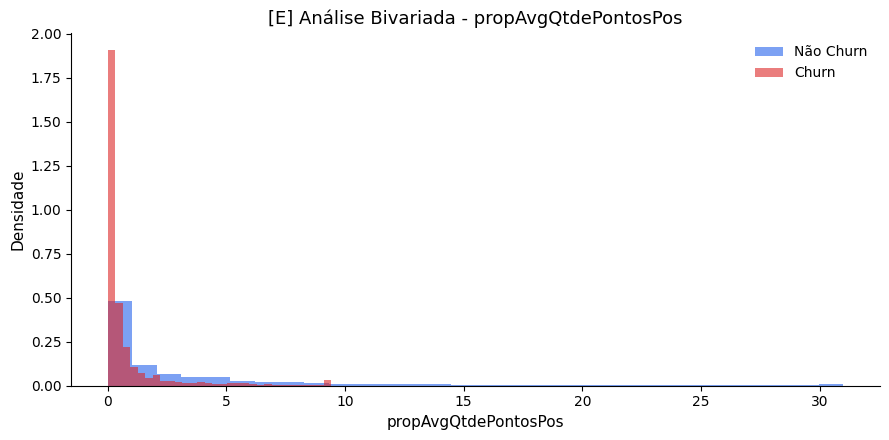

In [ ]:
feat = top8[7]
fig, ax = plt.subplots(figsize=(9, 4.5))
for cls, cor, lbl in [
    (0, CORES["azul"], "Não Churn"),
    (1, CORES["vermelho"], "Churn"),
]:
    vals = df_biv_plot[df_biv_plot["target"] == cls][feat]
    q1, q99 = vals.quantile(0.01), vals.quantile(0.99)
    vals_clip = vals.clip(q1, q99)
    ax.hist(vals_clip, bins=30, alpha=0.6, color=cor, label=lbl, density=True)
ax.set_title(f"[E] Análise Bivariada - {feat}")
ax.set_xlabel(feat)
ax.set_ylabel("Densidade")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

####  GRÁFICO 3 - Curva ROC

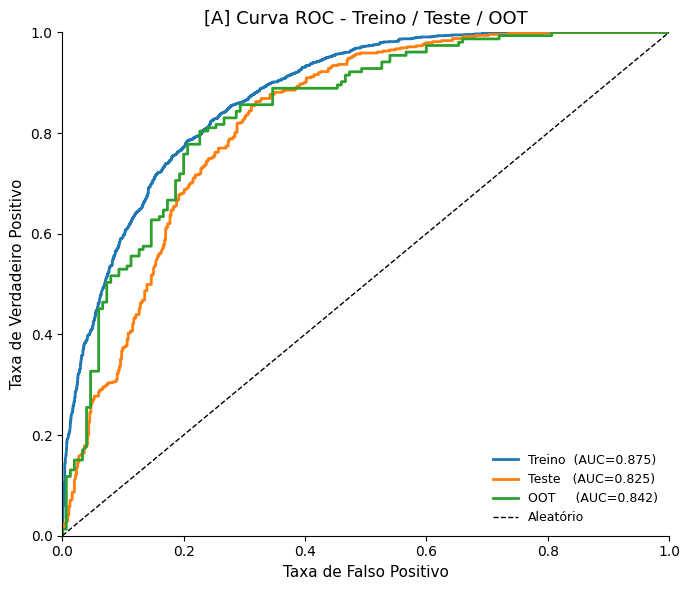

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
for y_true, y_prob, label, cor in [
    (y_train, y_prob_train, f"Treino  (AUC={auc_train:.3f})", CORES["azul"]),
    (y_test, y_prob_test, f"Teste   (AUC={auc_test:.3f})", CORES["verde"]),
    (y_oot, y_prob_oot, f"OOT     (AUC={auc_oot:.3f})", CORES["laranja"]),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax.plot(fpr, tpr, label=label, linewidth=2)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Aleatório")
ax.set_title("[A] Curva ROC - Treino / Teste / OOT")
ax.set_xlabel("Taxa de Falso Positivo")
ax.set_ylabel("Taxa de Verdadeiro Positivo")
ax.legend(fontsize=9, frameon=False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

####  GRÁFICO 4 - Curva de Gains / Lift

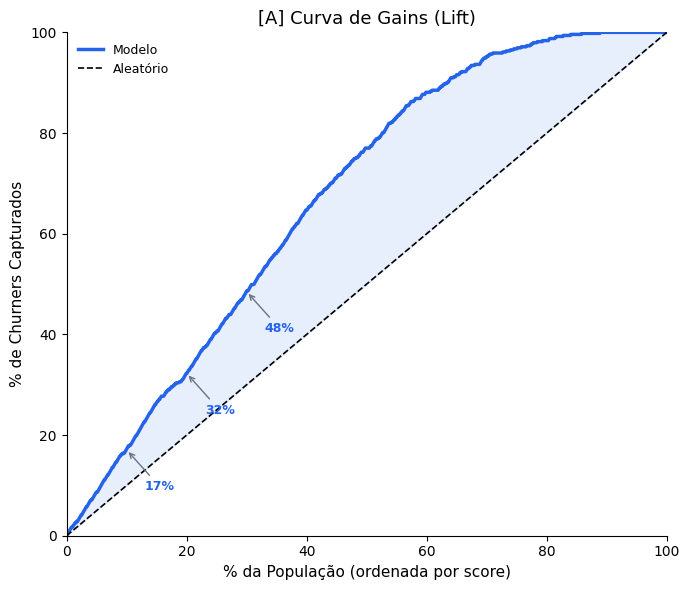

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
df_gains = df_lift.copy()
df_gains["cum_churners"] = df_gains["alvo"].cumsum()
df_gains["pct_pop"] = (df_gains.index + 1) / len(df_gains) * 100
df_gains["pct_captured"] = df_gains["cum_churners"] / total_churners * 100
ax.plot(
    df_gains["pct_pop"],
    df_gains["pct_captured"],
    color=CORES["azul"],
    linewidth=2.5,
    label="Modelo",
)
ax.plot([0, 100], [0, 100], "k--", linewidth=1.2, label="Aleatório")
ax.fill_between(
    df_gains["pct_pop"],
    df_gains["pct_captured"],
    df_gains["pct_pop"],
    alpha=0.1,
    color=CORES["azul"],
)
for d in [10, 20, 30]:
    idx = int(len(df_gains) * d / 100) - 1
    pct_cap = df_gains.iloc[idx]["pct_captured"]
    ax.annotate(
        f"{pct_cap:.0f}%",
        (d, pct_cap),
        xytext=(d + 3, pct_cap - 8),
        fontsize=9,
        arrowprops=dict(arrowstyle="->", color=CORES["cinza"]),
        color=CORES["azul"],
        fontweight="bold",
    )
ax.set_title("[A] Curva de Gains (Lift)")
ax.set_xlabel("% da População (ordenada por score)")
ax.set_ylabel("% de Churners Capturados")
ax.legend(fontsize=9, frameon=False)
ax.set_xlim([0, 100])
ax.set_ylim([0, 100])
plt.tight_layout()
plt.show()

####  GRÁFICO DE MÉTRICAS - Treino

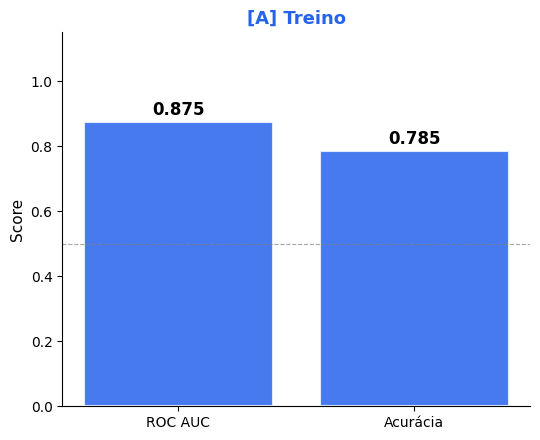

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
bars = ax.bar(
    ["ROC AUC", "Acurácia"],
    [auc_train, acc_train],
    color=[CORES["azul"], CORES["azul"]],
    alpha=0.85,
    edgecolor="white",
    linewidth=1.5,
)
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )
ax.set_title("[A] Treino", fontsize=13, color=CORES["azul"], fontweight="bold")
ax.set_ylim([0, 1.15])
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

####  GRÁFICO DE MÉTRICAS - Teste

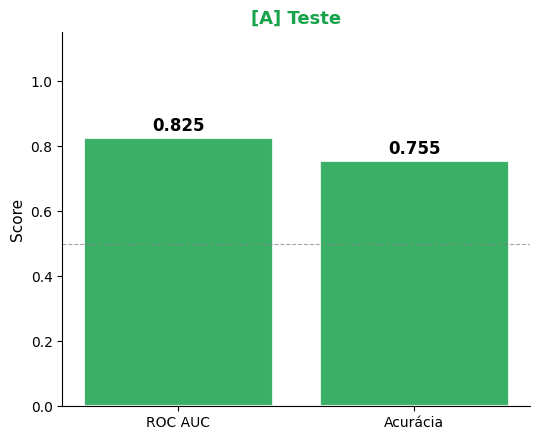

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
bars = ax.bar(
    ["ROC AUC", "Acurácia"],
    [auc_test, acc_test],
    color=[CORES["verde"], CORES["verde"]],
    alpha=0.85,
    edgecolor="white",
    linewidth=1.5,
)
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )
ax.set_title("[A] Teste", fontsize=13, color=CORES["verde"], fontweight="bold")
ax.set_ylim([0, 1.15])
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

####  GRÁFICO DE MÉTRICAS - OOT

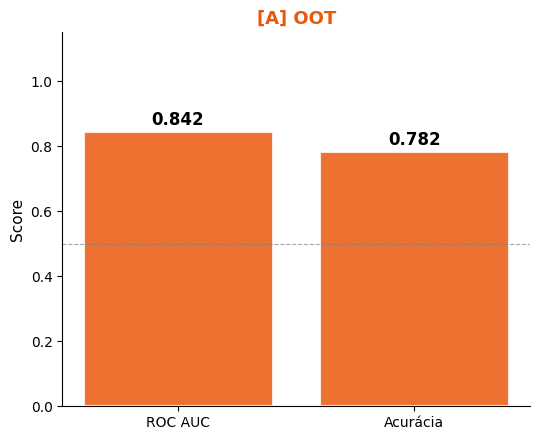

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
bars = ax.bar(
    ["ROC AUC", "Acurácia"],
    [auc_oot, acc_oot],
    color=[CORES["laranja"], CORES["laranja"]],
    alpha=0.85,
    edgecolor="white",
    linewidth=1.5,
)
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )
ax.set_title("[A] OOT", fontsize=13, color=CORES["laranja"], fontweight="bold")
ax.set_ylim([0, 1.15])
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()